# Case Study 1: Hospital Readmission Prediction Using Logistic Regression

**Objective:** Predict whether a diabetic patient will be **readmitted to the hospital within 30 days** of discharge, using a logistic regression model with L2 regularization.

**Dataset:** [Diabetes 130-US hospitals for years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (UCI Machine Learning Repository) — 101,766 hospital encounters for diabetic patients across 130 US hospitals, with demographic information, admission/discharge details, diagnoses, lab results, and medication data.

**Problem type:** Binary classification (Readmitted within 30 days = 1, Not readmitted within 30 days = 0)

**Model requirement:** Logistic Regression with L2 regularization, evaluated primarily using ROC-AUC.


## 1. Clinical Problem

Hospitals want to know, at the time a diabetic patient is discharged, **how likely that patient is to come back within 30 days**. A 30-day readmission usually means something in the original treatment or discharge plan did not go as intended.

Predicting this risk *before* the patient leaves the hospital can help clinical staff:

- **Prioritize follow-up calls or clinic visits** for patients flagged as high-risk.
- **Improve discharge planning** — e.g. arranging home health support or medication reconciliation for at-risk patients.
- **Identify patients who may need closer monitoring** of their diabetes management after leaving.
- **Reduce avoidable readmissions**, which are costly for hospitals and disruptive/stressful for patients.

It is important to be clear about the role of the model: it is a **decision-support tool**, not a replacement for clinical judgement. The model estimates a statistical risk based on patterns in historical data — it does not know anything about an individual patient beyond what is recorded in the dataset, and it should never be used to independently make medical decisions.


## 2. Import Libraries

In [1]:
# Uncomment the line below if running in a fresh environment (e.g. Google Colab)
# without these packages already installed.
# !pip install pandas numpy scikit-learn matplotlib seaborn --quiet

import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 3. Load and Inspect the Data

**Setup note:** This notebook expects the dataset files either as a folder containing `diabetic_data.csv` and `IDS_mapping.csv`, or as the original zip file
`diabetes+130-us+hospitals+for+years+1999-2008.zip` placed in the same directory as this notebook. If a zip file is found, it is extracted automatically into a `diabetes_data/` folder.


In [2]:
DATA_DIR = 'diabetes_data'
ZIP_CANDIDATES = [
    'diabetes+130-us+hospitals+for+years+1999-2008.zip',
    'diabetes_130-us_hospitals_for_years_1999-2008.zip'
]

def locate_file(filename, search_dirs=('.', DATA_DIR)):
    for d in search_dirs:
        path = os.path.join(d, filename)
        if os.path.exists(path):
            return path
    return None

diabetic_data_path = locate_file('diabetic_data.csv')

if diabetic_data_path is None:
    # Try to extract from a zip file if the raw CSVs are not present yet
    for zc in ZIP_CANDIDATES:
        if os.path.exists(zc):
            os.makedirs(DATA_DIR, exist_ok=True)
            with zipfile.ZipFile(zc, 'r') as z:
                z.extractall(DATA_DIR)
            diabetic_data_path = locate_file('diabetic_data.csv')
            break

if diabetic_data_path is None:
    raise FileNotFoundError(
        "Could not find 'diabetic_data.csv'. Place the extracted dataset in a "
        "'diabetes_data' folder next to this notebook, or place the original zip "
        "file in the same directory as this notebook."
    )

ids_mapping_path = locate_file('IDS_mapping.csv') or locate_file('IDS_mapping.csv', ('.', DATA_DIR))
print("Using data file:", diabetic_data_path)

df_raw = pd.read_csv(diabetic_data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Using data file: diabetes_data/diabetic_data.csv


Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [4]:
# Missing-value placeholder in this dataset is the string '?' rather than NaN
missing_summary = (df_raw == '?').sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
missing_pct = (missing_summary / len(df_raw) * 100).round(1)
pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})

,missing_count,missing_pct
weight,98569,96.9
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0


In [5]:
df_raw.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


`IDS_mapping.csv` provides human-readable descriptions for the numeric ID codes used in `admission_type_id`, `discharge_disposition_id`, and `admission_source_id`. We use it below to look up which discharge codes correspond to a patient having died or entered hospice — those encounters need special handling later (Section 5).

In [6]:
ids_map = pd.read_csv(ids_mapping_path, header=None, names=['id', 'description'])
# The file stacks three mapping tables; find where the discharge_disposition_id block starts
start = ids_map[ids_map['id'] == 'discharge_disposition_id'].index[0] + 1
end = ids_map[ids_map['id'] == 'admission_source_id'].index[0] - 1
discharge_map = ids_map.loc[start:end].dropna()
discharge_map.columns = ['discharge_disposition_id', 'description']
discharge_map[discharge_map['description'].str.contains('Expired|Hospice', case=False, na=False)]

,discharge_disposition_id,description
21,11,Expired
23,13,Hospice / home
24,14,Hospice / medical facility
29,19,"Expired at home. Medicaid only, hospice."
30,20,"Expired in a medical facility. Medicaid only, ..."
31,21,"Expired, place unknown. Medicaid only, hospice."


## 4. Understand the Target Variable

The `readmitted` column has three categories:

- `<30`  → the patient was readmitted within 30 days
- `>30`  → the patient was readmitted, but after more than 30 days
- `NO`   → the patient was not readmitted

Since the assignment asks specifically for **30-day readmission risk**, we convert this into a binary target:

- `1` = readmitted within 30 days (`<30`)
- `0` = everything else (`>30` or `NO`)

`>30` is grouped with `NO` because a readmission that happens more than a month later is generally attributable to a new, separate clinical episode rather than a failure of the original discharge plan — which is what a 30-day readmission metric is meant to capture.


In [7]:
print(df_raw['readmitted'].value_counts())
print()
print((df_raw['readmitted'].value_counts(normalize=True) * 100).round(2))

df_raw['readmit_30'] = (df_raw['readmitted'] == '<30').astype(int)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


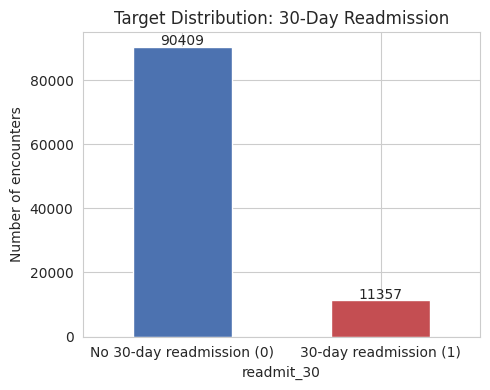

30-day readmission rate: 11.16%


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
df_raw['readmit_30'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0', '#C44E52'], ax=ax)
ax.set_xticklabels(['No 30-day readmission (0)', '30-day readmission (1)'], rotation=0)
ax.set_ylabel('Number of encounters')
ax.set_title('Target Distribution: 30-Day Readmission')
for i, v in enumerate(df_raw['readmit_30'].value_counts().sort_index()):
    ax.text(i, v + 500, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"30-day readmission rate: {df_raw['readmit_30'].mean()*100:.2f}%")

The target is clearly **imbalanced** — roughly 1 in 9 encounters results in a 30-day readmission. This has two consequences we address later: (1) we use **stratified splitting** so the train and test sets keep the same ratio, and (2) we rely on **ROC-AUC** rather than plain accuracy, since a model that always predicts "no readmission" would already be ~89% accurate while being clinically useless.

## 5. Data Cleaning

We make the following cleaning decisions, each explained below:

1. **Drop `weight`** — missing (`?`) for about 97% of encounters, so it carries almost no usable information.
2. **Drop `payer_code`** — missing for ~40% of rows and is an administrative/insurance field, not a clinical one; unlikely to be a meaningful predictor of readmission risk and not requested by the assignment.
3. **Remove encounters where the patient died or was discharged to hospice.** A patient who died or entered hospice care cannot be "readmitted" in any meaningful clinical sense, so including these rows would add noise/label errors to the target.
4. **Keep only the first encounter per patient.** Some patients (`patient_nbr`) appear multiple times in the dataset with several separate hospital stays. If we leave every encounter in and then split randomly into train/test, encounters from the *same patient* could end up in both sets, which leaks patient-specific information across the split. Keeping one (the first, chronologically by `encounter_id`) encounter per patient avoids this.
5. **Drop the small number of rows with a missing primary diagnosis (`diag_1`)** — only a handful of rows, not worth imputing.
6. **Drop identifier columns** (`encounter_id`, `patient_nbr`) after using them for cleaning — they are unique identifiers with no predictive meaning and must not be fed into the model.


In [9]:
df = df_raw.copy()

# 1) Drop weight (>96% missing)
print("Weight missing:", (df['weight'] == '?').mean()*100, "%")

# 3) Remove expired / hospice discharge dispositions (see IDS_mapping lookup above)
expired_hospice_codes = [11, 13, 14, 19, 20, 21]
before = df.shape[0]
df = df[~df['discharge_disposition_id'].isin(expired_hospice_codes)].copy()
print(f"Removed {before - df.shape[0]} expired/hospice encounters -> {df.shape[0]} remaining")

# 4) Keep first encounter per patient (avoid patient-level leakage across train/test)
before = df.shape[0]
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f"Removed {before - df.shape[0]} repeat encounters for the same patient -> {df.shape[0]} remaining")

# 5) Drop rows with missing primary diagnosis
before = df.shape[0]
df = df[df['diag_1'] != '?'].copy()
print(f"Dropped {before - df.shape[0]} rows with missing diag_1")

print("\nShape after cleaning:", df.shape)
print(df['readmit_30'].value_counts(normalize=True))

Weight missing: 96.85847925633315 %
Removed 2423 expired/hospice encounters -> 99343 remaining


Removed 29353 repeat encounters for the same patient -> 69990 remaining


Dropped 10 rows with missing diag_1

Shape after cleaning: (69980, 51)
readmit_30
0    0.910217
1    0.089783
Name: proportion, dtype: float64


In [10]:
# Recode remaining '?' placeholders that we DO keep
df['race'] = df['race'].replace('?', 'Unknown')

# medical_specialty: high cardinality (73 categories) with ~49% missing.
# We bucket it into the top 10 most common specialties + 'Missing' + 'Other'
# rather than one-hot encoding 73 sparse categories.
top_specialties = df.loc[df['medical_specialty'] != '?', 'medical_specialty'].value_counts().head(10).index.tolist()

def bucket_specialty(x):
    if x == '?':
        return 'Missing'
    return x if x in top_specialties else 'Other'

df['medical_specialty'] = df['medical_specialty'].apply(bucket_specialty)
print(df['medical_specialty'].value_counts())

medical_specialty
Missing                       33651
InternalMedicine              10640
Other                          5482
Family/GeneralPractice         4978
Emergency/Trauma               4392
Cardiology                     4208
Surgery-General                2205
Orthopedics                    1128
Orthopedics-Reconstructive     1041
Radiologist                     821
Nephrology                      797
Pulmonology                     637
Name: count, dtype: int64


In [11]:
# admission_type_id, discharge_disposition_id, admission_source_id are CODES, not
# continuous quantities (e.g. code 7 is not "more" of anything than code 3) so we
# treat them as categorical rather than numeric.
for c in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df[c] = df[c].astype(str)

# Drop columns we decided not to use, plus identifiers and the now-redundant original target
drop_cols = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'readmitted']
df = df.drop(columns=drop_cols)
print(df.shape)

(69980, 46)


## 6. Feature Engineering & Preprocessing

**Diagnosis codes.** `diag_1`, `diag_2`, and `diag_3` store ICD-9 diagnosis codes, and between them there are over 700 distinct raw values — far too many to one-hot encode directly. We group them into a small set of clinically meaningful categories using the standard ICD-9 chapter ranges (the same grouping scheme used in the original study that published this dataset, Strack et al. 2014): Circulatory, Respiratory, Digestive, Diabetes, Genitourinary, Injury, Musculoskeletal, Neoplasms, and Other.

**A note on "vitals".** The assignment description mentions vitals as an example predictor type. This dataset does **not** contain literal vital-sign measurements (blood pressure, heart rate, temperature, etc.) — it is an administrative/claims-style dataset. We use the closest available clinically-relevant proxies instead: `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, and the prior-utilization counts (`number_outpatient`, `number_emergency`, `number_inpatient`). This limitation is also noted in Section 15.


In [12]:
def group_diagnosis(code):
    """Map an ICD-9 diagnosis code string to a broad clinical category."""
    if pd.isna(code) or code == '?':
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        val = float(code)
    except ValueError:
        return 'Other'
    if 250 <= val < 251:
        return 'Diabetes'
    if (390 <= val <= 459) or val == 785:
        return 'Circulatory'
    if (460 <= val <= 519) or val == 786:
        return 'Respiratory'
    if (520 <= val <= 579) or val == 787:
        return 'Digestive'
    if 800 <= val <= 999:
        return 'Injury'
    if 710 <= val <= 739:
        return 'Musculoskeletal'
    if (580 <= val <= 629) or val == 788:
        return 'Genitourinary'
    if 140 <= val <= 239:
        return 'Neoplasms'
    return 'Other'

for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_group'] = df[c].apply(group_diagnosis)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])
df['diag_1_group'].value_counts()

diag_1_group
Circulatory        21390
Other              12124
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4696
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Name: count, dtype: int64

In [13]:
target = 'readmit_30'
X = df.drop(columns=[target])
y = df[target]

numeric_features = [c for c in X.columns if X[c].dtype.kind in 'if']
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"\nCategorical features ({len(categorical_features)}):", categorical_features)

Numeric features (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features (37): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']


Categorical variables are one-hot encoded and numeric variables are standardized, combined through a single `ColumnTransformer` so the exact same preprocessing is applied consistently to train and test data.

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

## 7. Train / Test Split

Because the target is imbalanced (~9% positive class), we use a **stratified split** so that the 30-day readmission rate is approximately the same in both the training set and the test set. Without stratification, a random split could by chance produce a test set with a noticeably different positive-class rate, which would make the evaluation metrics less reliable/comparable.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Positive rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Positive rate:", y_test.mean().round(4))

Train shape: (55984, 45)  Positive rate: 0.0898
Test shape:  (13996, 45)  Positive rate: 0.0898


## 8. Logistic Regression with L2 Regularization

**Logistic regression** models the log-odds of the positive class (30-day readmission) as a linear combination of the input features, and squashes the result into a probability between 0 and 1 using the sigmoid function.

**L2 regularization** adds a penalty term proportional to the *sum of squared coefficients* to the loss function the model minimizes. This discourages any single coefficient from growing too large, which:

- Reduces overfitting, especially important here because one-hot encoding expands our ~45 original columns into well over 100 features.
- Produces smoother, more stable coefficient estimates when features are correlated (e.g. several medication columns tend to move together).

We explicitly set `penalty='l2'` (with the `lbfgs` solver, which supports it) below rather than relying on a library default, and wrap the preprocessing + model into a single `Pipeline` so the same transformation is applied consistently.


In [16]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

log_reg_pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 9. Model Predictions

In [17]:
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

pd.DataFrame({'actual': y_test.values[:10], 'predicted_class': y_pred[:10], 'predicted_probability': y_proba[:10].round(3)})

,actual,predicted_class,predicted_probability
0,0,0,0.043
1,0,0,0.118
2,0,0,0.087
3,0,0,0.073
4,1,0,0.090
5,0,0,0.087
6,0,0,0.060
7,0,0,0.098
8,0,0,0.029
9,0,0,0.088


## 10. Model Evaluation

**ROC-AUC** is our primary metric. It measures the model's ability to *rank* a randomly chosen positive case (readmitted within 30 days) above a randomly chosen negative case, across every possible decision threshold at once. An AUC of 0.5 means the model is no better than random guessing; 1.0 means perfect separation. Because our target is imbalanced, ROC-AUC is far more informative here than accuracy.


In [18]:
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC:   {auc:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No 30-day readmit', '30-day readmit']))

ROC-AUC:   0.6368
Accuracy:  0.9100
Precision: 0.4500
Recall:    0.0072
F1-score:  0.0141

                   precision    recall  f1-score   support

No 30-day readmit       0.91      1.00      0.95     12739
   30-day readmit       0.45      0.01      0.01      1257

         accuracy                           0.91     13996
        macro avg       0.68      0.50      0.48     13996
     weighted avg       0.87      0.91      0.87     13996



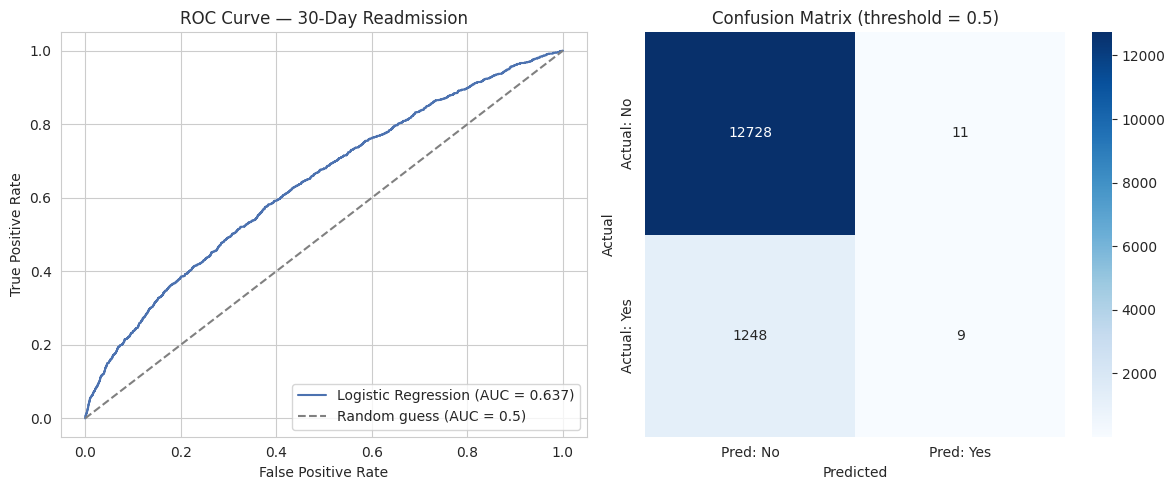

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', color='#4C72B0')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — 30-Day Readmission')
axes[0].legend(loc='lower right')

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
axes[1].set_title('Confusion Matrix (threshold = 0.5)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [20]:
print(f"At the default 0.5 threshold, the model correctly identifies "
      f"{rec*100:.1f}% of patients who are actually readmitted within 30 days (recall), "
      f"and {prec*100:.1f}% of the patients it flags as high-risk are indeed readmitted (precision).")
print(f"\nThe obtained ROC-AUC of {auc:.3f} indicates the model has some, but limited, "
      f"ability to separate patients who will be readmitted within 30 days from those who won't — "
      f"noticeably better than chance (0.5) but far from strong separation (closer to 1.0). "
      f"This is broadly consistent with published results on this dataset, where 30-day "
      f"readmission is known to be a genuinely hard prediction problem given the features available.")

At the default 0.5 threshold, the model correctly identifies 0.7% of patients who are actually readmitted within 30 days (recall), and 45.0% of the patients it flags as high-risk are indeed readmitted (precision).

The obtained ROC-AUC of 0.637 indicates the model has some, but limited, ability to separate patients who will be readmitted within 30 days from those who won't — noticeably better than chance (0.5) but far from strong separation (closer to 1.0). This is broadly consistent with published results on this dataset, where 30-day readmission is known to be a genuinely hard prediction problem given the features available.


## 11. False Positives vs. False Negatives

**False Positive (FP):** The model predicts a patient is at high risk of 30-day readmission, but the patient is *not* actually readmitted within 30 days.
- Possible consequences: unnecessary follow-up calls, extra monitoring resources spent on a patient who didn't need it, and potential patient anxiety from being flagged as "high risk."

**False Negative (FN):** The model predicts a patient is low risk, but the patient *is* actually readmitted within 30 days.
- Possible consequences: a missed opportunity to arrange extra follow-up or better discharge planning, and potentially worse outcomes for a patient who needed more support than they received.

**Which is "worse"?** This is not something the model can answer by itself — it depends on the hospital's own priorities, staffing capacity, and workflow. A hospital with abundant follow-up-care capacity might prefer to tolerate more false positives (cast a wide net) to avoid missing at-risk patients. A hospital with very limited follow-up resources might need to be more selective (fewer false positives) even if that means missing some true readmissions. We do not assign a hypothetical monetary cost here, since the assignment does not specify one — but the classification **threshold** is the practical lever a hospital would tune based on its own cost trade-off, which we explore next.


In [21]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}  (flagged high-risk, but not actually readmitted within 30 days)")
print(f"False Negatives: {fn}  (flagged low-risk, but actually readmitted within 30 days)")
print(f"True Positives:  {tp}")

True Negatives:  12728
False Positives: 11  (flagged high-risk, but not actually readmitted within 30 days)
False Negatives: 1248  (flagged low-risk, but actually readmitted within 30 days)
True Positives:  9


## 12. Effect of the Classification Threshold

By default, `predict()` uses a threshold of 0.5 on the predicted probability to decide the class. Lowering the threshold flags more patients as "high risk" (usually increasing recall at the cost of precision); raising it flags fewer patients (usually increasing precision at the cost of recall). We are **not** claiming any one threshold below is clinically "best" — that decision belongs to the hospital, based on its own follow-up capacity and risk tolerance.


In [22]:
thresholds_to_check = [0.3, 0.5, 0.7]
rows = []
for t in thresholds_to_check:
    preds_t = (y_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, preds_t, zero_division=0),
        'recall': recall_score(y_test, preds_t, zero_division=0),
        'f1_score': f1_score(y_test, preds_t, zero_division=0),
        'flagged_as_high_risk': preds_t.sum()
    })

threshold_df = pd.DataFrame(rows).round(4)
threshold_df

,threshold,precision,recall,f1_score,flagged_as_high_risk
0,0.3,0.3258,0.0573,0.0974,221
1,0.5,0.4500,0.0072,0.0141,20
2,0.7,0.5000,0.0016,0.0032,4


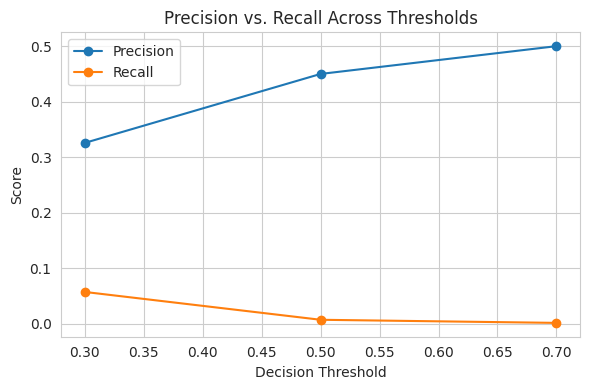

As the threshold increases from 0.3 to 0.7, precision and recall move in opposite directions — this is the fundamental precision/recall trade-off. A lower threshold casts a wider net (higher recall, more false positives); a higher threshold is more conservative (higher precision, more false negatives, i.e. more missed readmissions).


In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs. Recall Across Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

print("As the threshold increases from 0.3 to 0.7, precision and recall move in opposite "
      "directions — this is the fundamental precision/recall trade-off. A lower threshold "
      "casts a wider net (higher recall, more false positives); a higher threshold is more "
      "conservative (higher precision, more false negatives, i.e. more missed readmissions).")

## 13. Feature Interpretation

Logistic regression coefficients are directly interpretable: a positive coefficient means that feature (or category, for one-hot encoded variables) is associated with *higher* predicted odds of 30-day readmission, holding other features constant; a negative coefficient means the opposite. Because we one-hot encoded many categorical variables, we summarize only the top 15 most influential features by absolute coefficient size rather than listing every single encoded category.

**Important:** these coefficients describe *statistical association* learned from historical data, not clinical causation. A feature having a large coefficient does not mean it *causes* readmission.


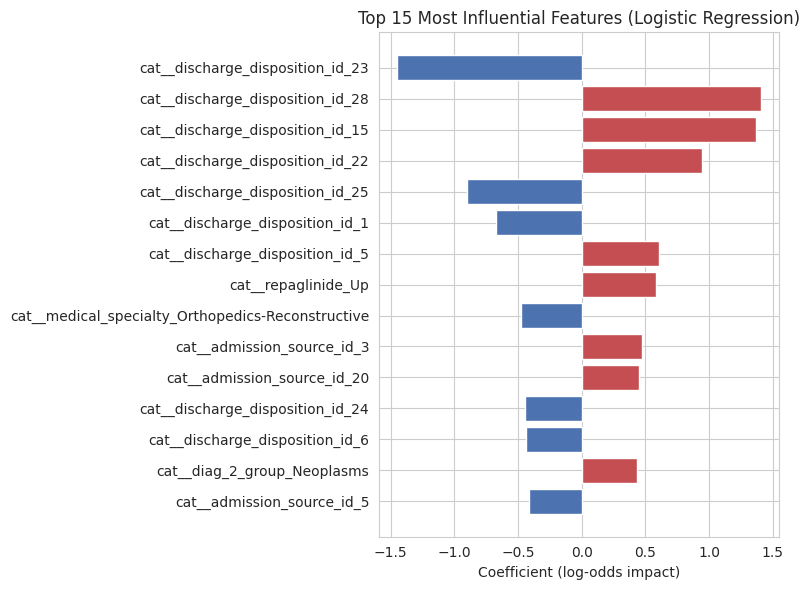

,feature,coefficient
44,cat__discharge_disposition_id_23,-1.447653
47,cat__discharge_disposition_id_28,1.410319
38,cat__discharge_disposition_id_15,1.365344
43,cat__discharge_disposition_id_22,0.941843
46,cat__discharge_disposition_id_25,-0.895828
35,cat__discharge_disposition_id_1,-0.670956
50,cat__discharge_disposition_id_5,0.609685
99,cat__repaglinide_Up,0.583898
79,cat__medical_specialty_Orthopedics-Reconstructive,-0.478955
65,cat__admission_source_id_3,0.477091


In [24]:
feature_names = log_reg_pipeline.named_steps['preprocess'].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
top_coefs = coef_df.sort_values('abs_coefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in top_coefs['coefficient']]
ax.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds impact)')
ax.set_title('Top 15 Most Influential Features (Logistic Regression)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_coefs[['feature', 'coefficient']]

## 14. Limitations

- **Historical, single-population data.** The dataset spans 1999–2008 from a specific set of US hospitals; clinical practice, coding standards, and patient populations have changed since then, so the model may not generalize to a current hospital setting without re-validation.
- **No true vital signs.** As noted earlier, the dataset lacks direct vital-sign measurements; we used administrative/utilization proxies instead, which likely omits clinically important signal.
- **Data quality.** Several fields (`weight`, `payer_code`, `medical_specialty`) had substantial missingness and were dropped or bucketed, which discards some information.
- **Moderate discriminative power.** The obtained ROC-AUC, while clearly better than chance, is well short of a highly discriminative model — 30-day readmission is genuinely difficult to predict from administrative data alone.
- **Correlation, not causation.** The logistic regression coefficients describe association within this historical dataset, not causal clinical relationships.
- **No external validation.** The model has only been evaluated on a held-out split of the *same* dataset; deploying a model like this in a real hospital would require prospective validation, clinical governance/oversight, and regular monitoring for performance drift.


## 15. Final Conclusion

In [25]:
print("=== Case Study 1 Summary ===")
print(f"Objective: Predict 30-day hospital readmission for diabetic patients")
print(f"Model: Logistic Regression with L2 regularization (C=1.0)")
print(f"Dataset size after cleaning: {df.shape[0]} encounters, {len(numeric_features)+len(categorical_features)} raw input features")
print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} (stratified)")
print()
print(f"ROC-AUC:   {auc:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print("The model shows modest but real predictive power for 30-day readmission risk. "
      "At the default threshold it favors precision over recall, meaning it currently misses "
      "many true readmissions (see the false-negative discussion above) — a hospital deploying "
      "a model like this would likely want to lower the threshold to catch more at-risk patients, "
      "accepting more false alarms in exchange. Given the moderate ROC-AUC and the limitations "
      "discussed above, this model would be best used as one input among several in a clinical "
      "discharge-planning workflow, not as a stand-alone decision-maker.")

=== Case Study 1 Summary ===
Objective: Predict 30-day hospital readmission for diabetic patients
Model: Logistic Regression with L2 regularization (C=1.0)
Dataset size after cleaning: 69980 encounters, 45 raw input features
Train/Test split: 55984 / 13996 (stratified)

ROC-AUC:   0.6368
Accuracy:  0.9100
Precision: 0.4500
Recall:    0.0072
F1-score:  0.0141

The model shows modest but real predictive power for 30-day readmission risk. At the default threshold it favors precision over recall, meaning it currently misses many true readmissions (see the false-negative discussion above) — a hospital deploying a model like this would likely want to lower the threshold to catch more at-risk patients, accepting more false alarms in exchange. Given the moderate ROC-AUC and the limitations discussed above, this model would be best used as one input among several in a clinical discharge-planning workflow, not as a stand-alone decision-maker.
